Accuracy : 0.6
Precision: 0.6
Recall   : 0.6
F1 Score : 0.6
Confusion Matrix:
 [[3 2]
 [2 3]]
Classification Report:
                  precision    recall  f1-score   support

Did Not Survive       0.60      0.60      0.60         5
       Survived       0.60      0.60      0.60         5

       accuracy                           0.60        10
      macro avg       0.60      0.60      0.60        10
   weighted avg       0.60      0.60      0.60        10



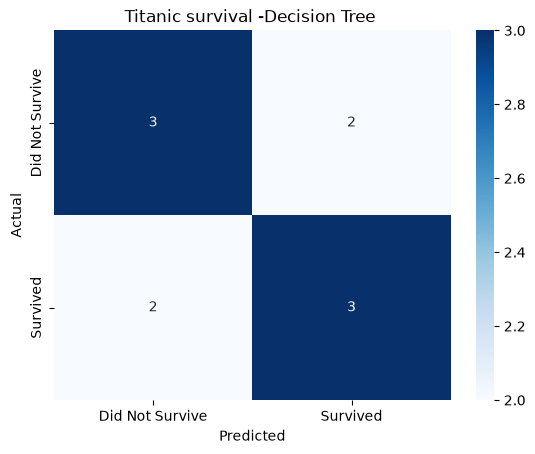

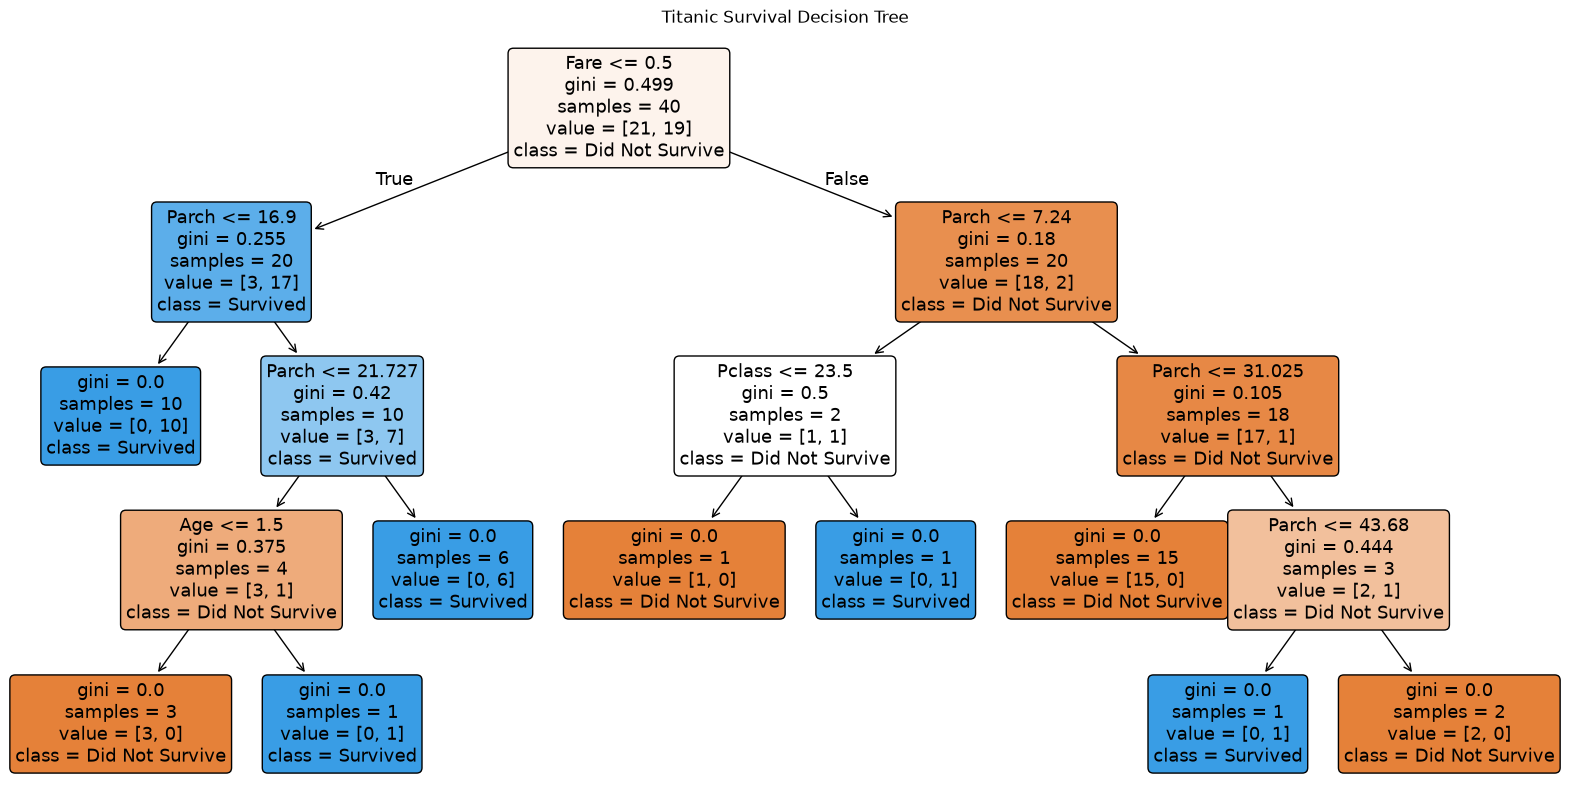

In [21]:
import numpy as np
import matplotlib.pyplot as plt 
import pandas as pd 
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier,plot_tree
import seaborn as sns
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,f1_score,recall_score,precision_score

df = pd.read_csv("titanic_with_null_values .csv")
df["Age"]=df["Age"].fillna(df["Age"].mean())
df["Fare"]=df["Fare"].fillna(df["Fare"].mean())
df["Embarked"]=df["Embarked"].fillna(df["Embarked"].mode()[0])
df=pd.get_dummies(df,columns=["Sex","Embarked"],drop_first=True )
df=df.drop("PassengerId",axis=1)
x=df.drop("Survived",axis=1)
y=df["Survived"]
model=DecisionTreeClassifier(criterion="gini" ,max_depth=5,random_state=42)
X_train,X_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)
model.fit(X_train,y_train)
y_pred=model.predict(X_test)
accuracy = accuracy_score(
    y_test,
    y_pred)
precision=precision_score(y_test,y_pred)    
recall=recall_score(y_test,y_pred)
f1=f1_score(y_test,y_pred)
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred,target_names=["Did Not Survive","Survived"],))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', xticklabels=["Did Not Survive","Survived"], yticklabels=["Did Not Survive","Survived"])
plt.title("Titanic survival -Decision Tree ")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
plt.figure(figsize=(20, 10))

plot_tree(
    model,
    feature_names=df.columns,class_names=["Did Not Survive","Survived"],filled=True,rounded=True)
plt.title("Titanic Survival Decision Tree")
plt.show()



